In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\student-marks-prediction\data\student_data.csv")

In [53]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


In [54]:
print(df.columns)

Index(['Student_ID', 'Age', 'Gender', 'Class', 'Study_Hours_Per_Day',
       'Attendance_Percentage', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Math_Score', 'Science_Score',
       'English_Score', 'Previous_Year_Score', 'Final_Percentage',
       'Performance_Level', 'Pass_Fail'],
      dtype='str')


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   str    
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   str    
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   str    
 7   Internet_Access             5000 non-null   str    
 8   Extracurricular_Activities  5000 non-null   str    
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 non-null   

In [56]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Class                         0
Study_Hours_Per_Day           0
Attendance_Percentage         0
Parental_Education            0
Internet_Access               0
Extracurricular_Activities    0
Math_Score                    0
Science_Score                 0
English_Score                 0
Previous_Year_Score           0
Final_Percentage              0
Performance_Level             0
Pass_Fail                     0
dtype: int64

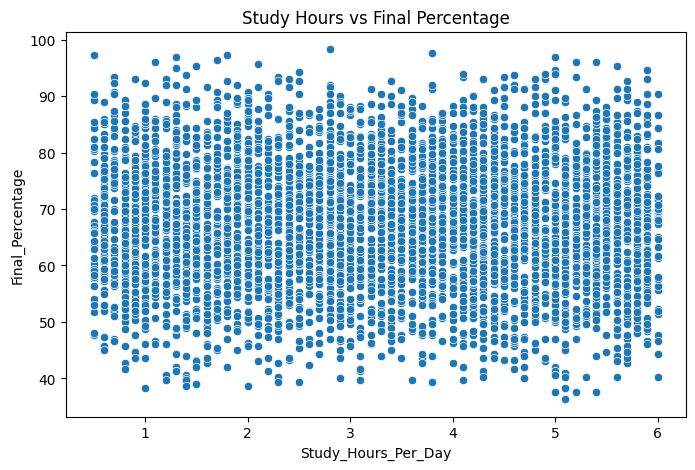

In [57]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Study_Hours_Per_Day'],
    y=df['Final_Percentage']
)

plt.title("Study Hours vs Final Percentage")

plt.show()

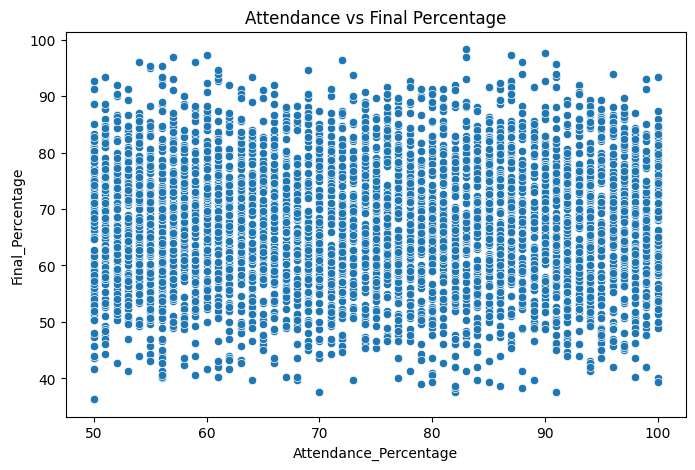

In [58]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Attendance_Percentage'],
    y=df['Final_Percentage']
)

plt.title("Attendance vs Final Percentage")

plt.show()

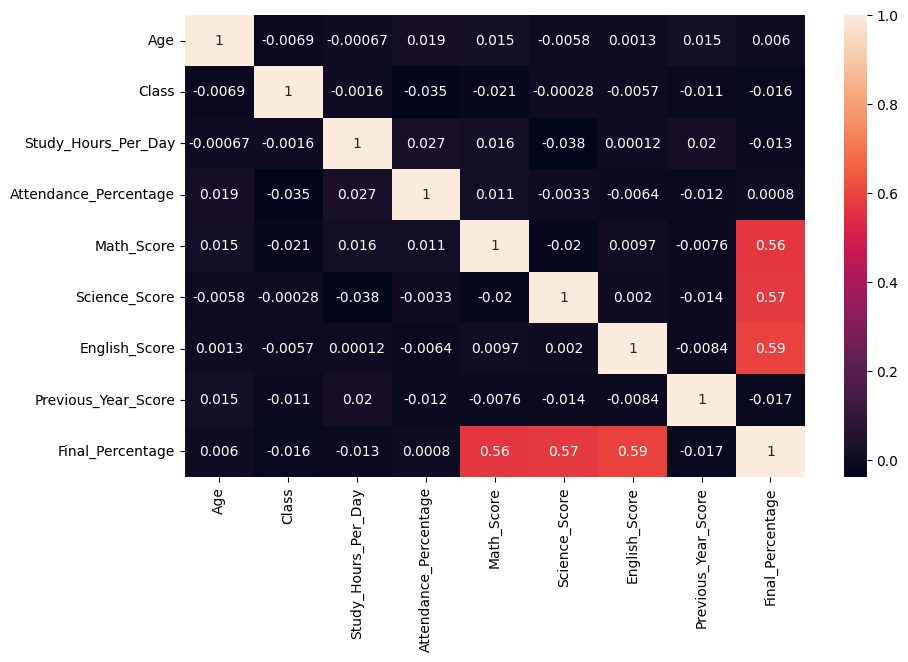

In [59]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [61]:
X = df[['Study_Hours_Per_Day', 'Attendance_Percentage']]

y = df['Final_Percentage']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
predictions = model.predict(X_test)

In [65]:
mae = mean_absolute_error(y_test, predictions)

print(mae)

8.932661948041401


In [66]:
new_data = pd.DataFrame({
    'Study_Hours_Per_Day': [5],
    'Attendance_Percentage': [90]
})

prediction = model.predict(new_data)

print(prediction)

[67.50231812]


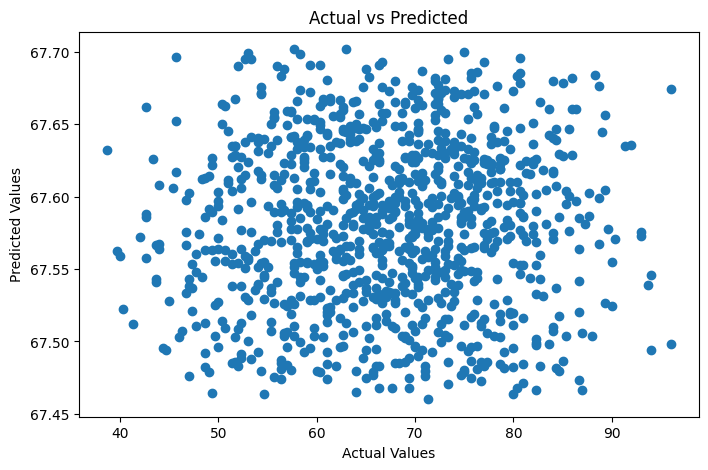

In [67]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

In [76]:
plt.savefig(
    r"C:\Users\Admin\Desktop\student-marks-prediction\images\study_vs_percentage.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [77]:
plt.savefig(
    r"C:\Users\Admin\Desktop\student-marks-prediction\images\attendance_vs_percentage.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [78]:
plt.savefig(
    r"C:\Users\Admin\Desktop\student-marks-prediction\images\heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [79]:
plt.savefig(
    r"C:\Users\Admin\Desktop\student-marks-prediction\images\performance_levels.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [80]:
plt.savefig(
    r"C:\Users\Admin\Desktop\student-marks-prediction\images\pass_fail_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>